📍 Cargando mapa de CABA...
✅ Polígono de CABA cargado: 48 barrios

🏢 CONFIGURACIÓN DEL PROBLEMA VRP
📍 Depósito: Retiro (Depósito)
🚛 Camiones disponibles: 3
📦 Capacidad por camión: 15 paquetes
📦 Pedidos a generar: 30

✅ 30 pedidos generados DENTRO de CABA
✅ Matriz cargada desde cache: vrp_caba_31.npz

🗺️ Matriz de distancias: (31, 31)
   Distancia promedio: 13234 metros

🚛 Optimizando rutas de reparto...

✅ SOLUCIÓN ÓPTIMA ENCONTRADA
🎯 Distancia total: 129.18 km

🚛 CAMIÓN 1
------------------------------------------------------------
  0. 🏢 Salida del Depósito
  1. 📦 Entregar Pedido #28
  2. 📦 Entregar Pedido #27
  3. 📦 Entregar Pedido #18
  4. 📦 Entregar Pedido #26
  5. 📦 Entregar Pedido #2
  6. 📦 Entregar Pedido #20
  7. 📦 Entregar Pedido #7
  8. 📦 Entregar Pedido #11
  9. 📦 Entregar Pedido #15
  10. 📦 Entregar Pedido #16
  11. 📦 Entregar Pedido #25
  12. 📦 Entregar Pedido #12
  13. 📦 Entregar Pedido #24
  14. 📦 Entregar Pedido #9
  15. 📦 Entregar Pedido #5
  16. 🏢 Regreso al Depósito

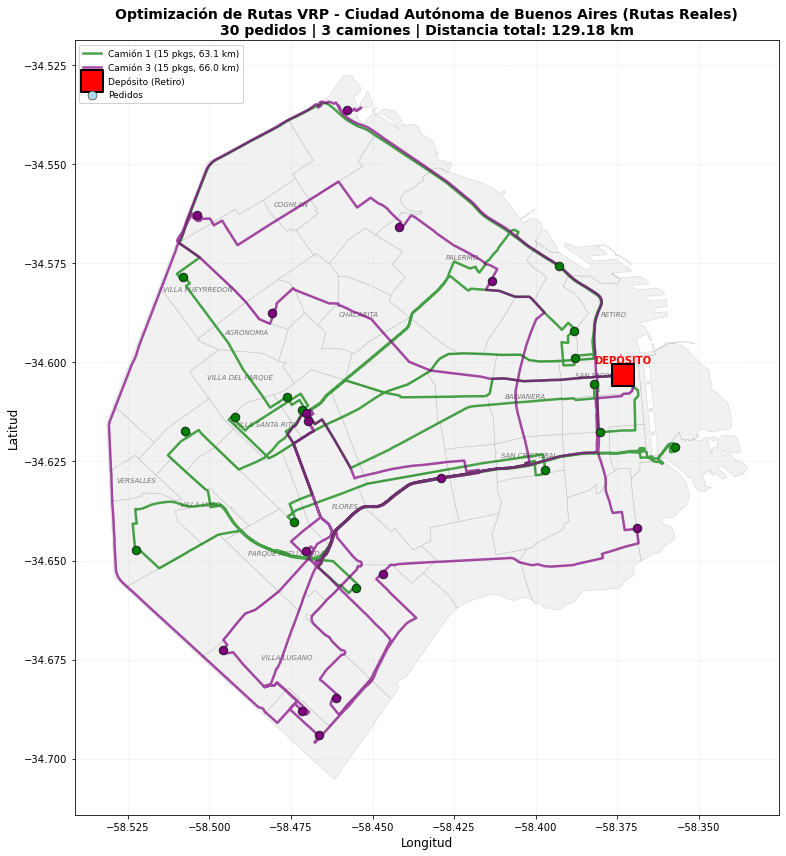

✅ Visualización completada con rutas reales de OSM


In [ ]:
# Instalación
# !pip install ortools requests geopandas polyline

import numpy as np
import requests
import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point
import matplotlib.pyplot as plt
import polyline
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

# ============= CARGAR POLÍGONO DE CABA =============
print("📍 Cargando mapa de CABA...")
barrios_df = pd.read_csv('/Users/gerardoaboulafia/Library/Mobile Documents/com~apple~CloudDocs/UCA/optuca/Vehicle-Routing-Problem/utils/barrios copy.csv',encoding='latin-1')
barrios_df['geometry'] = barrios_df['WKT'].apply(wkt.loads)
barrios_gdf = gpd.GeoDataFrame(barrios_df, geometry='geometry', crs='EPSG:4326')

# Crear polígono unificado de CABA
caba_polygon = barrios_gdf.unary_union
print(f"✅ Polígono de CABA cargado: {len(barrios_gdf)} barrios")

# ============= CONFIGURACIÓN DEL PROBLEMA =============
DEPOT = {"name": "Retiro (Depósito)", "lat": -34.603277, "lon": -58.373207}
NUM_VEHICLES = 3
VEHICLE_CAPACITY = 15
NUM_ORDERS = 30

# ============= FUNCIÓN: GENERAR PEDIDOS DENTRO DE CABA =============
def generate_random_deliveries_in_caba(caba_polygon, num_orders, seed=None):
    """
    Genera pedidos con coordenadas aleatorias DENTRO del polígono de CABA
    
    Args:
        caba_polygon: Polígono de CABA (shapely Polygon o MultiPolygon)
        num_orders: cantidad de pedidos
        seed: semilla para reproducibilidad
    
    Returns:
        orders: lista de ubicaciones dentro de CABA
    """
    if seed is not None:
        np.random.seed(seed)
    
    orders = []
    minx, miny, maxx, maxy = caba_polygon.bounds
    
    attempts = 0
    max_attempts = num_orders * 100  # Límite para evitar loop infinito
    
    while len(orders) < num_orders and attempts < max_attempts:
        # Generar punto aleatorio dentro del bounding box
        random_lon = np.random.uniform(minx, maxx)
        random_lat = np.random.uniform(miny, maxy)
        point = Point(random_lon, random_lat)
        
        # Verificar si está dentro del polígono de CABA
        if caba_polygon.contains(point):
            order = {
                'order_id': len(orders) + 1,
                'lat': random_lat,
                'lon': random_lon,
                'type': 'order'
            }
            orders.append(order)
        
        attempts += 1
    
    if len(orders) < num_orders:
        print(f"⚠️ Solo se generaron {len(orders)}/{num_orders} pedidos dentro de CABA")
    
    return orders

# ============= FUNCIÓN: OBTENER RUTA REAL CON OSRM =============
def get_osrm_route_geometry(locations_indices, all_locations):
    """
    Obtiene la geometría de la ruta real usando OSRM
    
    Args:
        locations_indices: lista de índices de ubicaciones en orden
        all_locations: lista completa de ubicaciones
    
    Returns:
        route_coords: array de coordenadas [lon, lat] de la ruta real
    """
    if len(locations_indices) < 2:
        return None
    
    # Construir coordenadas en formato OSRM (lon,lat)
    coords = ";".join([f"{all_locations[i]['lon']},{all_locations[i]['lat']}" 
                      for i in locations_indices])
    
    url = f"http://router.project-osrm.org/route/v1/driving/{coords}?overview=full&geometries=polyline"
    
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        if data['code'] == 'Ok':
            # Decodificar polyline
            encoded_polyline = data['routes'][0]['geometry']
            decoded = polyline.decode(encoded_polyline)
            
            # Convertir a formato [lon, lat]
            route_coords = np.array([[coord[1], coord[0]] for coord in decoded])
            return route_coords
        else:
            return None
            
    except Exception as e:
        print(f"⚠️ Error obteniendo geometría de ruta: {e}")
        return None

# ============= FUNCIÓN: CALCULAR DISTANCIAS CON OSRM =============
def calculate_distance_matrix_osrm(locations, use_cache=True, cache_name='distances'):
    """Calcula matriz de distancias usando OSRM API"""
    n = len(locations)
    distance_matrix = np.zeros((n, n))
    
    cache_file = f'{cache_name}_{n}.npz'
    
    if use_cache:
        try:
            cache = np.load(cache_file)
            print(f"✅ Matriz cargada desde cache: {cache_file}")
            return cache['distance']
        except:
            print("📡 Calculando matriz de distancias con OSRM...")
    
    coords = ";".join([f"{loc['lon']},{loc['lat']}" for loc in locations])
    url = f"http://router.project-osrm.org/table/v1/driving/{coords}?annotations=distance"
    
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        data = response.json()
        
        if data['code'] == 'Ok':
            distance_matrix = np.array(data['distances'])
            
            if use_cache:
                np.savez(cache_file, distance=distance_matrix)
                print(f"💾 Matriz guardada en cache: {cache_file}")
        else:
            print(f"⚠️ Error en OSRM: {data['code']}, usando distancia euclidiana")
            distance_matrix = calculate_euclidean_distances(locations)
            
    except Exception as e:
        print(f"❌ Error conectando a OSRM: {e}")
        print("⚠️ Usando distancias euclidianas como fallback")
        distance_matrix = calculate_euclidean_distances(locations)
    
    return distance_matrix.astype(int)

def calculate_euclidean_distances(locations):
    """Distancia euclidiana como fallback"""
    n = len(locations)
    distance_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            lat1, lon1 = locations[i]['lat'], locations[i]['lon']
            lat2, lon2 = locations[j]['lat'], locations[j]['lon']
            distance_matrix[i][j] = np.sqrt(
                ((lat2 - lat1) * 111000)**2 + 
                ((lon2 - lon1) * 111000 * np.cos(np.radians(lat1)))**2
            )
    
    return distance_matrix

# ============= GENERAR ESCENARIO =============
print("\n🏢 CONFIGURACIÓN DEL PROBLEMA VRP")
print("="*60)
print(f"📍 Depósito: {DEPOT['name']}")
print(f"🚛 Camiones disponibles: {NUM_VEHICLES}")
print(f"📦 Capacidad por camión: {VEHICLE_CAPACITY} paquetes")
print(f"📦 Pedidos a generar: {NUM_ORDERS}")
print("="*60)

# Generar pedidos dentro del polígono de CABA
orders = generate_random_deliveries_in_caba(caba_polygon, NUM_ORDERS, seed=42)
print(f"\n✅ {len(orders)} pedidos generados DENTRO de CABA")

# Combinar: [depot] + [orders]
all_locations = [DEPOT] + orders

# Calcular matriz de distancias
distance_matrix = calculate_distance_matrix_osrm(all_locations, use_cache=True, cache_name='vrp_caba')

print(f"\n🗺️ Matriz de distancias: {distance_matrix.shape}")
print(f"   Distancia promedio: {distance_matrix[distance_matrix > 0].mean():.0f} metros")

# ============= MODELADO OR-TOOLS =============
def create_data_model():
    data = {}
    data['distance_matrix'] = distance_matrix.tolist()
    data['demands'] = [0] + [1] * len(orders)
    data['vehicle_capacities'] = [VEHICLE_CAPACITY] * NUM_VEHICLES
    data['num_vehicles'] = NUM_VEHICLES
    data['depot'] = 0
    return data

data = create_data_model()

manager = pywrapcp.RoutingIndexManager(
    len(data['distance_matrix']),
    data['num_vehicles'],
    data['depot']
)
routing = pywrapcp.RoutingModel(manager)

def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return data['distance_matrix'][from_node][to_node]

transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

def demand_callback(from_index):
    from_node = manager.IndexToNode(from_index)
    return data['demands'][from_node]

demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
routing.AddDimensionWithVehicleCapacity(
    demand_callback_index,
    0,
    data['vehicle_capacities'],
    True,
    'Capacity'
)

search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
search_parameters.local_search_metaheuristic = (
    routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
)
search_parameters.time_limit.seconds = 30

# ============= RESOLVER =============
print("\n🚛 Optimizando rutas de reparto...\n")
solution = routing.SolveWithParameters(search_parameters)

# ============= RESULTADOS =============
if solution:
    print("✅ SOLUCIÓN ÓPTIMA ENCONTRADA")
    print("="*60)
    print(f"🎯 Distancia total: {solution.ObjectiveValue() / 1000:.2f} km")
    print("="*60)
    
    total_distance = 0
    total_packages = 0
    all_routes = []
    
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        route_distance = 0
        route_load = 0
        route_nodes = []
        
        print(f"\n🚛 CAMIÓN {vehicle_id + 1}")
        print("-"*60)
        
        step = 0
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            location = all_locations[node_index]
            route_load += data['demands'][node_index]
            route_nodes.append(node_index)
            
            if node_index == 0:
                print(f"  {step}. 🏢 Salida del Depósito")
            else:
                print(f"  {step}. 📦 Entregar Pedido #{location['order_id']}")
            
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)
            step += 1
        
        print(f"  {step}. 🏢 Regreso al Depósito")
        
        print(f"\n  📊 Distancia: {route_distance / 1000:.2f} km")
        print(f"  📦 Paquetes: {route_load}/{data['vehicle_capacities'][vehicle_id]}")
        print("-"*60)
        
        total_distance += route_distance
        total_packages += route_load
        all_routes.append({
            'vehicle': vehicle_id + 1,
            'distance': route_distance,
            'packages': route_load,
            'nodes': route_nodes
        })
    
    print("\n" + "="*60)
    print("📊 RESUMEN FINAL")
    print("="*60)
    print(f"  🎯 Distancia total: {total_distance / 1000:.2f} km")
    print(f"  📦 Paquetes entregados: {total_packages}/{len(orders)}")
    print(f"  🚛 Camiones utilizados: {sum(1 for r in all_routes if r['packages'] > 0)}/{NUM_VEHICLES}")
    print(f"  📈 Utilización: {(total_packages / (NUM_VEHICLES * VEHICLE_CAPACITY)) * 100:.1f}%")
    print("="*60)

# ============= VISUALIZACIÓN CON RUTAS REALES =============
if solution:
    print("\n🗺️ Generando visualización con rutas reales de OSM...")
    
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Plotear barrios
    barrios_gdf.plot(ax=ax, color='lightgray', edgecolor='gray', linewidth=0.5, alpha=0.3)
    
    # Nombres de barrios
    for idx, row in barrios_gdf.iterrows():
        if idx % 3 == 0:
            centroid = row.geometry.centroid
            ax.text(centroid.x, centroid.y, row['BARRIO'], 
                   fontsize=7, ha='center', alpha=0.5, style='italic')
    
    # Depósito
    ax.scatter(DEPOT['lon'], DEPOT['lat'], c='red', s=500, marker='s', 
              label='Depósito (Retiro)', zorder=5, edgecolors='black', linewidths=2)
    ax.text(DEPOT['lon'], DEPOT['lat']+0.003, 'DEPÓSITO', 
           fontsize=10, ha='center', fontweight='bold', color='red')
    
    # Pedidos
    orders_lons = [o['lon'] for o in orders]
    orders_lats = [o['lat'] for o in orders]
    ax.scatter(orders_lons, orders_lats, c='lightblue', s=80, 
              label='Pedidos', zorder=3, edgecolors='black', linewidths=0.5)
    
    # Colores para rutas
    colors = ['green', 'orange', 'purple', 'brown', 'pink', 'cyan']
    
    # Plotear rutas REALES de OSRM
    print("📍 Obteniendo geometrías de rutas reales...")
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        route_indices = []
        
        # Recolectar todos los índices de la ruta
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route_indices.append(node_index)
            index = solution.Value(routing.NextVar(index))
        
        # Agregar regreso al depósito
        node_index = manager.IndexToNode(index)
        route_indices.append(node_index)
        
        if len(route_indices) > 2:
            # Obtener geometría real de OSRM
            route_geometry = get_osrm_route_geometry(route_indices, all_locations)
            route_info = all_routes[vehicle_id]
            
            if route_geometry is not None:
                ax.plot(route_geometry[:, 0], route_geometry[:, 1], 
                       c=colors[vehicle_id % len(colors)], linewidth=2.5, 
                       alpha=0.7,
                       label=f'Camión {vehicle_id + 1} ({route_info["packages"]} pkgs, {route_info["distance"]/1000:.1f} km)', 
                       zorder=4)
                
                # Marcar puntos de entrega en la ruta
                for idx in route_indices:
                    if idx != 0:  # Excluir depósito
                        loc = all_locations[idx]
                        ax.plot(loc['lon'], loc['lat'], 'o',
                               c=colors[vehicle_id % len(colors)], 
                               markersize=8, zorder=5,
                               markeredgecolor='black', markeredgewidth=0.5)
            else:
                # Fallback a líneas rectas si falla OSRM
                print(f"⚠️ Usando líneas rectas para Camión {vehicle_id + 1}")
                route_coords = np.array([[all_locations[i]['lon'], all_locations[i]['lat']] 
                                        for i in route_indices])
                ax.plot(route_coords[:, 0], route_coords[:, 1], 
                       c=colors[vehicle_id % len(colors)], linewidth=2.5, 
                       marker='o', markersize=7, alpha=0.7,
                       label=f'Camión {vehicle_id + 1} ({route_info["packages"]} pkgs, {route_info["distance"]/1000:.1f} km)', 
                       zorder=4)
    
    ax.set_xlabel('Longitud', fontsize=12)
    ax.set_ylabel('Latitud', fontsize=12)
    ax.set_title(f'Optimización de Rutas VRP - Ciudad Autónoma de Buenos Aires (Rutas Reales)\n' + 
                f'{len(orders)} pedidos | {NUM_VEHICLES} camiones | Distancia total: {total_distance/1000:.2f} km', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.2, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualización completada con rutas reales de OSM")

📍 Cargando mapa de CABA...
✅ Polígono de CABA cargado: 48 barrios

🏢 CONFIGURACIÓN DEL PROBLEMA VRP
📍 Depósito: Retiro (Depósito)
🚛 Camiones disponibles: 3
📦 Capacidad por camión: 15 paquetes
📦 Pedidos a generar: 30

✅ 30 pedidos generados DENTRO de CABA
✅ Matriz cargada desde cache: vrp_caba_31.npz

🗺️ Matriz de distancias: (31, 31)
   Distancia promedio: 13234 metros

🚛 Optimizando rutas de reparto...

✅ SOLUCIÓN ÓPTIMA ENCONTRADA
🎯 Distancia total: 129.18 km

🚛 CAMIÓN 1
------------------------------------------------------------
  0. 🏢 Salida del Depósito
  1. 📦 Entregar Pedido #28
  2. 📦 Entregar Pedido #27
  3. 📦 Entregar Pedido #18
  4. 📦 Entregar Pedido #26
  5. 📦 Entregar Pedido #2
  6. 📦 Entregar Pedido #20
  7. 📦 Entregar Pedido #7
  8. 📦 Entregar Pedido #11
  9. 📦 Entregar Pedido #15
  10. 📦 Entregar Pedido #16
  11. 📦 Entregar Pedido #25
  12. 📦 Entregar Pedido #12
  13. 📦 Entregar Pedido #24
  14. 📦 Entregar Pedido #9
  15. 📦 Entregar Pedido #5
  16. 🏢 Regreso al Depósito

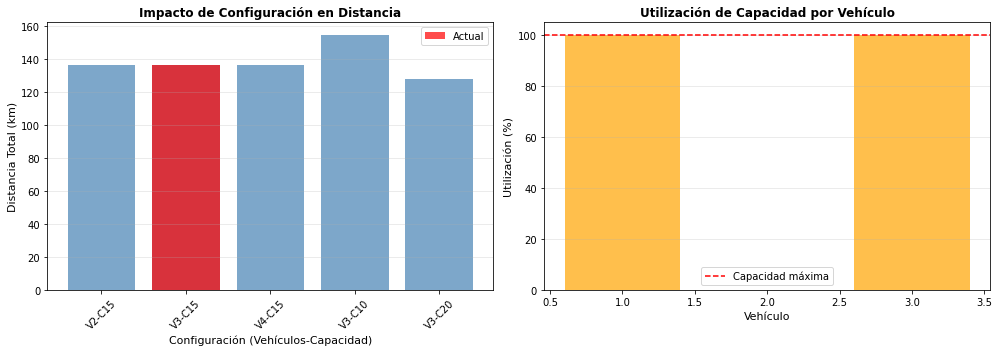


🗺️ Generando visualización con rutas reales de OSM...
📍 Obteniendo geometrías de rutas reales...


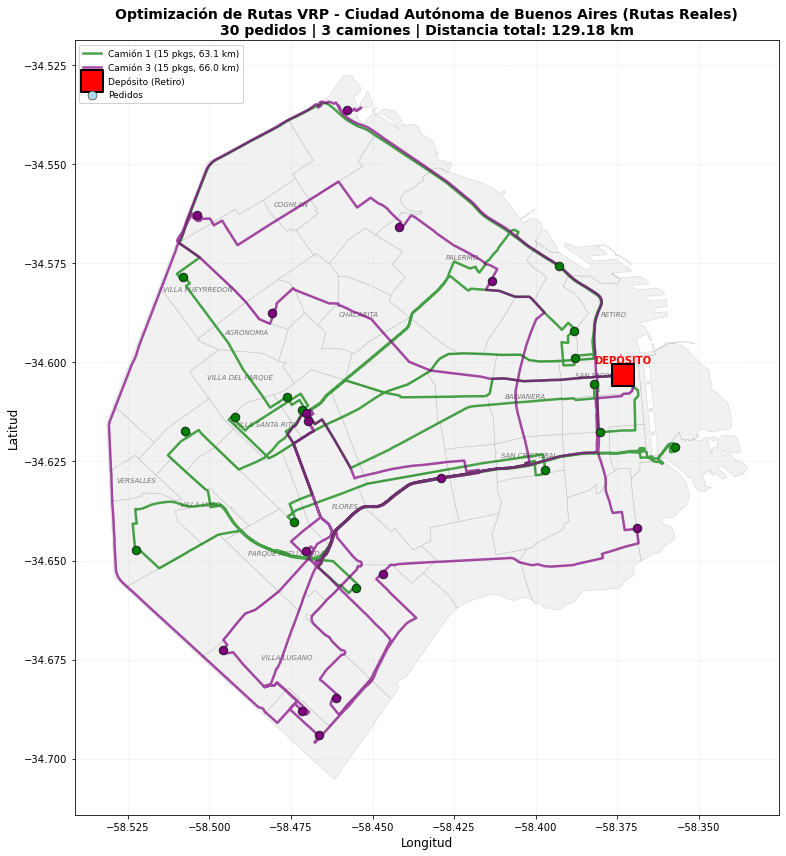

✅ Visualización completada con rutas reales de OSM


In [3]:
# Instalación
# !pip install ortools requests geopandas polyline

import numpy as np
import requests
import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point
import matplotlib.pyplot as plt
import polyline
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

# ============= CARGAR POLÍGONO DE CABA =============
print("📍 Cargando mapa de CABA...")
barrios_df = pd.read_csv('/Users/gerardoaboulafia/Library/Mobile Documents/com~apple~CloudDocs/UCA/optuca/Vehicle-Routing-Problem/utils/barrios copy.csv',encoding='latin-1')
barrios_df['geometry'] = barrios_df['WKT'].apply(wkt.loads)
barrios_gdf = gpd.GeoDataFrame(barrios_df, geometry='geometry', crs='EPSG:4326')

caba_polygon = barrios_gdf.unary_union
print(f"✅ Polígono de CABA cargado: {len(barrios_gdf)} barrios")

# ============= CONFIGURACIÓN DEL PROBLEMA =============
DEPOT = {"name": "Retiro (Depósito)", "lat": -34.603277, "lon": -58.373207}
NUM_VEHICLES = 3
VEHICLE_CAPACITY = 15
NUM_ORDERS = 30

# ============= FUNCIONES AUXILIARES =============
def generate_random_deliveries_in_caba(caba_polygon, num_orders, seed=None):
    """Genera pedidos dentro del polígono de CABA"""
    if seed is not None:
        np.random.seed(seed)
    
    orders = []
    minx, miny, maxx, maxy = caba_polygon.bounds
    
    attempts = 0
    max_attempts = num_orders * 100
    
    while len(orders) < num_orders and attempts < max_attempts:
        random_lon = np.random.uniform(minx, maxx)
        random_lat = np.random.uniform(miny, maxy)
        point = Point(random_lon, random_lat)
        
        if caba_polygon.contains(point):
            order = {
                'order_id': len(orders) + 1,
                'lat': random_lat,
                'lon': random_lon,
                'type': 'order'
            }
            orders.append(order)
        
        attempts += 1
    
    return orders

def get_osrm_route_geometry(locations_indices, all_locations):
    """Obtiene geometría de ruta real usando OSRM"""
    if len(locations_indices) < 2:
        return None
    
    coords = ";".join([f"{all_locations[i]['lon']},{all_locations[i]['lat']}" 
                      for i in locations_indices])
    
    url = f"http://router.project-osrm.org/route/v1/driving/{coords}?overview=full&geometries=polyline"
    
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        if data['code'] == 'Ok':
            encoded_polyline = data['routes'][0]['geometry']
            decoded = polyline.decode(encoded_polyline)
            route_coords = np.array([[coord[1], coord[0]] for coord in decoded])
            return route_coords
        else:
            return None
            
    except Exception as e:
        return None

def calculate_distance_matrix_osrm(locations, use_cache=True, cache_name='distances'):
    """Calcula matriz de distancias usando OSRM API"""
    n = len(locations)
    distance_matrix = np.zeros((n, n))
    
    cache_file = f'{cache_name}_{n}.npz'
    
    if use_cache:
        try:
            cache = np.load(cache_file)
            print(f"✅ Matriz cargada desde cache: {cache_file}")
            return cache['distance']
        except:
            print("📡 Calculando matriz de distancias con OSRM...")
    
    coords = ";".join([f"{loc['lon']},{loc['lat']}" for loc in locations])
    url = f"http://router.project-osrm.org/table/v1/driving/{coords}?annotations=distance"
    
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        data = response.json()
        
        if data['code'] == 'Ok':
            distance_matrix = np.array(data['distances'])
            
            if use_cache:
                np.savez(cache_file, distance=distance_matrix)
                print(f"💾 Matriz guardada en cache: {cache_file}")
        else:
            distance_matrix = calculate_euclidean_distances(locations)
            
    except Exception as e:
        print(f"❌ Error conectando a OSRM: {e}")
        distance_matrix = calculate_euclidean_distances(locations)
    
    return distance_matrix.astype(int)

def calculate_euclidean_distances(locations):
    """Distancia euclidiana como fallback"""
    n = len(locations)
    distance_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            lat1, lon1 = locations[i]['lat'], locations[i]['lon']
            lat2, lon2 = locations[j]['lat'], locations[j]['lon']
            distance_matrix[i][j] = np.sqrt(
                ((lat2 - lat1) * 111000)**2 + 
                ((lon2 - lon1) * 111000 * np.cos(np.radians(lat1)))**2
            )
    
    return distance_matrix

# ============= FUNCIONES DE ANÁLISIS DE OPTIMIZACIÓN =============

def calculate_reduced_costs(solution, routing, manager, distance_matrix, used_arcs):
    """
    Calcula costos reducidos: el costo de usar arcos que NO están en la solución óptima
    
    Interpretación: Si el costo reducido es grande, significa que usar ese arco 
    sería muy costoso comparado con la solución actual.
    """
    n = len(distance_matrix)
    reduced_costs = []
    
    for i in range(n):
        for j in range(n):
            if i != j and (i, j) not in used_arcs:
                # Costo de este arco no utilizado
                arc_cost = distance_matrix[i][j]
                
                # Costo promedio de arcos utilizados desde i
                used_from_i = [distance_matrix[i][k] for (f, k) in used_arcs if f == i]
                avg_cost_from_i = np.mean(used_from_i) if used_from_i else arc_cost
                
                # Costo reducido = diferencia con alternativa actual
                reduced_cost = arc_cost - avg_cost_from_i
                
                reduced_costs.append({
                    'from': i,
                    'to': j,
                    'arc_cost': arc_cost / 1000,  # en km
                    'avg_alternative': avg_cost_from_i / 1000,
                    'reduced_cost': reduced_cost / 1000,
                    'relative_increase': (reduced_cost / avg_cost_from_i * 100) if avg_cost_from_i > 0 else 0
                })
    
    return pd.DataFrame(reduced_costs)

def calculate_shadow_prices(solution, routing, manager, data, all_locations):
    """
    Calcula precios sombra: valor marginal de relajar restricciones
    
    1. Precio sombra de capacidad: ¿Cuánto vale tener 1 unidad más de capacidad?
    2. Precio sombra de vehículos: ¿Cuánto vale tener 1 vehículo más?
    """
    shadow_prices = {}
    
    # 1. PRECIO SOMBRA DE CAPACIDAD
    # Simular incremento de capacidad y ver impacto
    capacity_analysis = []
    
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        route_load = 0
        route_distance = 0
        
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route_load += data['demands'][node_index]
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)
        
        # Capacidad no utilizada (holgura)
        slack = data['vehicle_capacities'][vehicle_id] - route_load
        
        # Distancia promedio por paquete en esta ruta
        distance_per_package = route_distance / route_load if route_load > 0 else 0
        
        capacity_analysis.append({
            'vehicle': vehicle_id + 1,
            'capacity': data['vehicle_capacities'][vehicle_id],
            'used': route_load,
            'slack': slack,
            'utilization': (route_load / data['vehicle_capacities'][vehicle_id]) * 100,
            'route_distance_km': route_distance / 1000,
            'distance_per_package_km': distance_per_package / 1000,
            'marginal_value_capacity': distance_per_package / 1000  # Precio sombra aproximado
        })
    
    shadow_prices['capacity_analysis'] = pd.DataFrame(capacity_analysis)
    
    # 2. PRECIO SOMBRA DE VEHÍCULOS
    # Valor de agregar un vehículo = distancia que podríamos ahorrar
    total_distance = solution.ObjectiveValue()
    avg_distance_per_vehicle = total_distance / data['num_vehicles']
    
    # Vehículos activos (con carga > 0)
    active_vehicles = sum(1 for ca in capacity_analysis if ca['used'] > 0)
    
    shadow_prices['vehicle_shadow_price'] = {
        'current_vehicles': data['num_vehicles'],
        'active_vehicles': active_vehicles,
        'avg_distance_per_vehicle_km': avg_distance_per_vehicle / 1000,
        'marginal_value_vehicle': avg_distance_per_vehicle / 1000,  # Ahorro potencial
        'recommendation': 'Reducir vehículos' if active_vehicles < data['num_vehicles'] 
                         else 'Configuración óptima'
    }
    
    return shadow_prices

def sensitivity_analysis(distance_matrix, data, orders, all_locations):
    """
    Análisis de sensibilidad: ¿Qué pasa si cambiamos parámetros?
    """
    print("\n" + "="*70)
    print("📊 ANÁLISIS DE SENSIBILIDAD")
    print("="*70)
    
    results = []
    
    # Probar diferentes configuraciones
    configurations = [
        {'vehicles': 2, 'capacity': 15},
        {'vehicles': 3, 'capacity': 15},  # Actual
        {'vehicles': 4, 'capacity': 15},
        {'vehicles': 3, 'capacity': 10},
        {'vehicles': 3, 'capacity': 20},
    ]
    
    for config in configurations:
        print(f"\n🔄 Probando: {config['vehicles']} vehículos, capacidad {config['capacity']}...")
        
        # Verificar factibilidad
        total_capacity = config['vehicles'] * config['capacity']
        if total_capacity < len(orders):
            results.append({
                'vehicles': config['vehicles'],
                'capacity': config['capacity'],
                'total_capacity': total_capacity,
                'feasible': False,
                'distance_km': None,
                'utilization': None
            })
            print(f"   ❌ No factible (capacidad insuficiente)")
            continue
        
        # Resolver con nueva configuración
        temp_data = {
            'distance_matrix': distance_matrix.tolist(),
            'demands': [0] + [1] * len(orders),
            'vehicle_capacities': [config['capacity']] * config['vehicles'],
            'num_vehicles': config['vehicles'],
            'depot': 0
        }
        
        temp_manager = pywrapcp.RoutingIndexManager(
            len(temp_data['distance_matrix']),
            temp_data['num_vehicles'],
            temp_data['depot']
        )
        temp_routing = pywrapcp.RoutingModel(temp_manager)
        
        def temp_distance_callback(from_index, to_index):
            from_node = temp_manager.IndexToNode(from_index)
            to_node = temp_manager.IndexToNode(to_index)
            return temp_data['distance_matrix'][from_node][to_node]
        
        temp_transit_callback_index = temp_routing.RegisterTransitCallback(temp_distance_callback)
        temp_routing.SetArcCostEvaluatorOfAllVehicles(temp_transit_callback_index)
        
        def temp_demand_callback(from_index):
            from_node = temp_manager.IndexToNode(from_index)
            return temp_data['demands'][from_node]
        
        temp_demand_callback_index = temp_routing.RegisterUnaryTransitCallback(temp_demand_callback)
        temp_routing.AddDimensionWithVehicleCapacity(
            temp_demand_callback_index,
            0,
            temp_data['vehicle_capacities'],
            True,
            'Capacity'
        )
        
        temp_search_parameters = pywrapcp.DefaultRoutingSearchParameters()
        temp_search_parameters.first_solution_strategy = (
            routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
        )
        temp_search_parameters.time_limit.seconds = 10
        
        temp_solution = temp_routing.SolveWithParameters(temp_search_parameters)
        
        if temp_solution:
            distance = temp_solution.ObjectiveValue() / 1000
            utilization = (len(orders) / total_capacity) * 100
            
            results.append({
                'vehicles': config['vehicles'],
                'capacity': config['capacity'],
                'total_capacity': total_capacity,
                'feasible': True,
                'distance_km': distance,
                'utilization': utilization
            })
            print(f"   ✅ Distancia: {distance:.2f} km, Utilización: {utilization:.1f}%")
        else:
            results.append({
                'vehicles': config['vehicles'],
                'capacity': config['capacity'],
                'total_capacity': total_capacity,
                'feasible': False,
                'distance_km': None,
                'utilization': None
            })
            print(f"   ❌ No se encontró solución")
    
    return pd.DataFrame(results)

def analyze_optimization_metrics(solution, routing, manager, data, all_locations, distance_matrix):
    """Función principal de análisis de optimización"""
    
    print("\n" + "="*70)
    print("📈 ANÁLISIS DE OPTIMIZACIÓN AVANZADO")
    print("="*70)
    
    # 1. Extraer arcos utilizados
    used_arcs = set()
    route_details = []
    
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        
        while not routing.IsEnd(index):
            from_node = manager.IndexToNode(index)
            next_index = solution.Value(routing.NextVar(index))
            to_node = manager.IndexToNode(next_index)
            
            used_arcs.add((from_node, to_node))
            
            route_details.append({
                'vehicle': vehicle_id + 1,
                'from': from_node,
                'to': to_node,
                'distance_km': distance_matrix[from_node][to_node] / 1000
            })
            
            index = next_index
    
    # 2. COSTOS REDUCIDOS
    print("\n📉 COSTOS REDUCIDOS (Arcos no utilizados)")
    print("-" * 70)
    reduced_costs_df = calculate_reduced_costs(solution, routing, manager, distance_matrix, used_arcs)
    
    # Top 10 arcos con mayor costo reducido (más costosos de usar)
    top_expensive = reduced_costs_df.nlargest(10, 'reduced_cost')
    print("\n🔴 Top 10 arcos MÁS costosos si se usaran:")
    print(top_expensive[['from', 'to', 'arc_cost', 'reduced_cost', 'relative_increase']].to_string(index=False))
    
    # Top 10 arcos con menor costo reducido (más baratos, alternativas viables)
    top_cheap = reduced_costs_df.nsmallest(10, 'reduced_cost')
    print("\n🟢 Top 10 arcos MENOS costosos (alternativas viables):")
    print(top_cheap[['from', 'to', 'arc_cost', 'reduced_cost', 'relative_increase']].to_string(index=False))
    
    # 3. PRECIOS SOMBRA
    print("\n" + "="*70)
    print("💰 PRECIOS SOMBRA (Valor marginal de recursos)")
    print("="*70)
    shadow_prices = calculate_shadow_prices(solution, routing, manager, data, all_locations)
    
    print("\n🚛 Análisis de Capacidad por Vehículo:")
    print(shadow_prices['capacity_analysis'].to_string(index=False))
    
    print("\n📊 Interpretación de Precio Sombra de Capacidad:")
    avg_marginal = shadow_prices['capacity_analysis']['marginal_value_capacity'].mean()
    print(f"   Valor marginal promedio: {avg_marginal:.2f} km por unidad de capacidad")
    print(f"   → Aumentar capacidad en 1 unidad reduciría distancia en ~{avg_marginal:.2f} km")
    
    print("\n🚗 Análisis de Vehículos:")
    for key, value in shadow_prices['vehicle_shadow_price'].items():
        print(f"   {key}: {value}")
    
    # 4. ESTADÍSTICAS DE RUTAS UTILIZADAS
    print("\n" + "="*70)
    print("📋 ESTADÍSTICAS DE ARCOS UTILIZADOS")
    print("="*70)
    routes_df = pd.DataFrame(route_details)
    
    print(f"\nTotal de arcos utilizados: {len(used_arcs)}")
    print(f"Distancia promedio por arco: {routes_df['distance_km'].mean():.2f} km")
    print(f"Distancia máxima en un arco: {routes_df['distance_km'].max():.2f} km")
    print(f"Distancia mínima en un arco: {routes_df['distance_km'].min():.2f} km")
    
    # 5. ANÁLISIS DE SENSIBILIDAD
    sensitivity_df = sensitivity_analysis(distance_matrix, data, orders, all_locations)
    
    print("\n" + "="*70)
    print("📊 RESUMEN DE SENSIBILIDAD")
    print("="*70)
    print(sensitivity_df.to_string(index=False))
    
    # Visualizar sensibilidad
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Distancia vs Configuración
    feasible = sensitivity_df[sensitivity_df['feasible'] == True]
    if not feasible.empty:
        config_labels = [f"V{row['vehicles']}-C{row['capacity']}" 
                        for _, row in feasible.iterrows()]
        
        axes[0].bar(config_labels, feasible['distance_km'], color='steelblue', alpha=0.7)
        axes[0].set_xlabel('Configuración (Vehículos-Capacidad)', fontsize=11)
        axes[0].set_ylabel('Distancia Total (km)', fontsize=11)
        axes[0].set_title('Impacto de Configuración en Distancia', fontsize=12, fontweight='bold')
        axes[0].grid(axis='y', alpha=0.3)
        axes[0].tick_params(axis='x', rotation=45)
        
        # Marcar configuración actual
        current_config = f"V{data['num_vehicles']}-C{data['vehicle_capacities'][0]}"
        current_idx = config_labels.index(current_config) if current_config in config_labels else -1
        if current_idx >= 0:
            axes[0].bar(current_idx, feasible.iloc[current_idx]['distance_km'], 
                       color='red', alpha=0.7, label='Actual')
            axes[0].legend()
    
    # Gráfico 2: Utilización de Capacidad
    capacity_df = shadow_prices['capacity_analysis']
    axes[1].bar(capacity_df['vehicle'], capacity_df['utilization'], color='orange', alpha=0.7)
    axes[1].axhline(y=100, color='red', linestyle='--', label='Capacidad máxima')
    axes[1].set_xlabel('Vehículo', fontsize=11)
    axes[1].set_ylabel('Utilización (%)', fontsize=11)
    axes[1].set_title('Utilización de Capacidad por Vehículo', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'reduced_costs': reduced_costs_df,
        'shadow_prices': shadow_prices,
        'sensitivity': sensitivity_df,
        'routes': routes_df
    }

# ============= GENERAR ESCENARIO =============
print("\n🏢 CONFIGURACIÓN DEL PROBLEMA VRP")
print("="*60)
print(f"📍 Depósito: {DEPOT['name']}")
print(f"🚛 Camiones disponibles: {NUM_VEHICLES}")
print(f"📦 Capacidad por camión: {VEHICLE_CAPACITY} paquetes")
print(f"📦 Pedidos a generar: {NUM_ORDERS}")
print("="*60)

orders = generate_random_deliveries_in_caba(caba_polygon, NUM_ORDERS, seed=42)
print(f"\n✅ {len(orders)} pedidos generados DENTRO de CABA")

all_locations = [DEPOT] + orders
distance_matrix = calculate_distance_matrix_osrm(all_locations, use_cache=True, cache_name='vrp_caba')

print(f"\n🗺️ Matriz de distancias: {distance_matrix.shape}")
print(f"   Distancia promedio: {distance_matrix[distance_matrix > 0].mean():.0f} metros")

# ============= MODELADO OR-TOOLS =============
def create_data_model():
    data = {}
    data['distance_matrix'] = distance_matrix.tolist()
    data['demands'] = [0] + [1] * len(orders)
    data['vehicle_capacities'] = [VEHICLE_CAPACITY] * NUM_VEHICLES
    data['num_vehicles'] = NUM_VEHICLES
    data['depot'] = 0
    return data

data = create_data_model()

manager = pywrapcp.RoutingIndexManager(
    len(data['distance_matrix']),
    data['num_vehicles'],
    data['depot']
)
routing = pywrapcp.RoutingModel(manager)

def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return data['distance_matrix'][from_node][to_node]

transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

def demand_callback(from_index):
    from_node = manager.IndexToNode(from_index)
    return data['demands'][from_node]

demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
routing.AddDimensionWithVehicleCapacity(
    demand_callback_index,
    0,
    data['vehicle_capacities'],
    True,
    'Capacity'
)

search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
search_parameters.local_search_metaheuristic = (
    routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
)
search_parameters.time_limit.seconds = 30

# ============= RESOLVER =============
print("\n🚛 Optimizando rutas de reparto...\n")
solution = routing.SolveWithParameters(search_parameters)

# ============= RESULTADOS =============
if solution:
    print("✅ SOLUCIÓN ÓPTIMA ENCONTRADA")
    print("="*60)
    print(f"🎯 Distancia total: {solution.ObjectiveValue() / 1000:.2f} km")
    print("="*60)
    
    total_distance = 0
    total_packages = 0
    all_routes = []
    
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        route_distance = 0
        route_load = 0
        route_nodes = []
        
        print(f"\n🚛 CAMIÓN {vehicle_id + 1}")
        print("-"*60)
        
        step = 0
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            location = all_locations[node_index]
            route_load += data['demands'][node_index]
            route_nodes.append(node_index)
            
            if node_index == 0:
                print(f"  {step}. 🏢 Salida del Depósito")
            else:
                print(f"  {step}. 📦 Entregar Pedido #{location['order_id']}")
            
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)
            step += 1
        
        print(f"  {step}. 🏢 Regreso al Depósito")
        
        print(f"\n  📊 Distancia: {route_distance / 1000:.2f} km")
        print(f"  📦 Paquetes: {route_load}/{data['vehicle_capacities'][vehicle_id]}")
        print("-"*60)
        
        total_distance += route_distance
        total_packages += route_load
        all_routes.append({
            'vehicle': vehicle_id + 1,
            'distance': route_distance,
            'packages': route_load,
            'nodes': route_nodes
        })
    
    print("\n" + "="*60)
    print("📊 RESUMEN FINAL")
    print("="*60)
    print(f"  🎯 Distancia total: {total_distance / 1000:.2f} km")
    print(f"  📦 Paquetes entregados: {total_packages}/{len(orders)}")
    print(f"  🚛 Camiones utilizados: {sum(1 for r in all_routes if r['packages'] > 0)}/{NUM_VEHICLES}")
    print(f"  📈 Utilización: {(total_packages / (NUM_VEHICLES * VEHICLE_CAPACITY)) * 100:.1f}%")
    print("="*60)
    
    # ============= ANÁLISIS DE OPTIMIZACIÓN =============
    analysis_results = analyze_optimization_metrics(
        solution, routing, manager, data, all_locations, distance_matrix
    )

# ============= VISUALIZACIÓN CON RUTAS REALES =============
if solution:
    print("\n🗺️ Generando visualización con rutas reales de OSM...")
    
    fig, ax = plt.subplots(figsize=(16, 12))
    
    barrios_gdf.plot(ax=ax, color='lightgray', edgecolor='gray', linewidth=0.5, alpha=0.3)
    
    for idx, row in barrios_gdf.iterrows():
        if idx % 3 == 0:
            centroid = row.geometry.centroid
            ax.text(centroid.x, centroid.y, row['BARRIO'], 
                   fontsize=7, ha='center', alpha=0.5, style='italic')
    
    ax.scatter(DEPOT['lon'], DEPOT['lat'], c='red', s=500, marker='s', 
              label='Depósito (Retiro)', zorder=5, edgecolors='black', linewidths=2)
    ax.text(DEPOT['lon'], DEPOT['lat']+0.003, 'DEPÓSITO', 
           fontsize=10, ha='center', fontweight='bold', color='red')
    
    orders_lons = [o['lon'] for o in orders]
    orders_lats = [o['lat'] for o in orders]
    ax.scatter(orders_lons, orders_lats, c='lightblue', s=80, 
              label='Pedidos', zorder=3, edgecolors='black', linewidths=0.5)
    
    colors = ['green', 'orange', 'purple', 'brown', 'pink', 'cyan']
    
    print("📍 Obteniendo geometrías de rutas reales...")
    for vehicle_id in range(data['num_vehicles']):
        index = routing.Start(vehicle_id)
        route_indices = []
        
        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            route_indices.append(node_index)
            index = solution.Value(routing.NextVar(index))
        
        node_index = manager.IndexToNode(index)
        route_indices.append(node_index)
        
        if len(route_indices) > 2:
            route_geometry = get_osrm_route_geometry(route_indices, all_locations)
            route_info = all_routes[vehicle_id]
            
            if route_geometry is not None:
                ax.plot(route_geometry[:, 0], route_geometry[:, 1], 
                       c=colors[vehicle_id % len(colors)], linewidth=2.5, 
                       alpha=0.7,
                       label=f'Camión {vehicle_id + 1} ({route_info["packages"]} pkgs, {route_info["distance"]/1000:.1f} km)', 
                       zorder=4)
                
                for idx in route_indices:
                    if idx != 0:
                        loc = all_locations[idx]
                        ax.plot(loc['lon'], loc['lat'], 'o',
                               c=colors[vehicle_id % len(colors)], 
                               markersize=8, zorder=5,
                               markeredgecolor='black', markeredgewidth=0.5)
            else:
                route_coords = np.array([[all_locations[i]['lon'], all_locations[i]['lat']] 
                                        for i in route_indices])
                ax.plot(route_coords[:, 0], route_coords[:, 1], 
                       c=colors[vehicle_id % len(colors)], linewidth=2.5, 
                       marker='o', markersize=7, alpha=0.7,
                       label=f'Camión {vehicle_id + 1} ({route_info["packages"]} pkgs, {route_info["distance"]/1000:.1f} km)', 
                       zorder=4)
    
    ax.set_xlabel('Longitud', fontsize=12)
    ax.set_ylabel('Latitud', fontsize=12)
    ax.set_title(f'Optimización de Rutas VRP - Ciudad Autónoma de Buenos Aires (Rutas Reales)\n' + 
                f'{len(orders)} pedidos | {NUM_VEHICLES} camiones | Distancia total: {total_distance/1000:.2f} km', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.2, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualización completada con rutas reales de OSM")